# 03 · Results review — fit diagnostics and the residual list

Reads only `results/`. Use this to sanity-check the OLS before quoting numbers.

In [1]:
import json, pandas as pd, numpy as np, matplotlib.pyplot as plt, statsmodels.formula.api as smf
pd.set_option("display.max_rows", 200, "display.width", 180)
r = pd.read_csv("../results/residuals.csv"); s = json.load(open("../results/fit_summary.json")); rob = pd.read_csv("../results/robustness.csv")
{k: s[k] for k in ["n","slope","slope_se_hc3","slope_ci95_boot","r2","r2_ci95_boot","resid_sd","pua_split","quadrant_counts"]}

{'n': 66,
 'slope': -0.7079911557119922,
 'slope_se_hc3': 0.05617244413617735,
 'slope_ci95_boot': [-0.817710067681662, -0.5954458328903149],
 'r2': 0.6519590867416685,
 'r2_ci95_boot': [0.501068209465345, 0.782469555719596],
 'resid_sd': 14.055694036494653,
 'pua_split': 49.599999999999994,
 'quadrant_counts': {'higher unaffordability, lower MDD-W than predicted': 19,
  'lower unaffordability, higher MDD-W than predicted': 18,
  'lower unaffordability, lower MDD-W than predicted': 15,
  'higher unaffordability, higher MDD-W than predicted': 14}}

## Robustness table
Does the PUA coefficient survive alternative specifications? Are the residual rankings stable (`corr_resid_headline` = Spearman with headline residuals)?

In [2]:
rob.round(3)

,model,n,term,coef,se,p,r2,spearman_resid_vs_headline,note
0,OLS mddw ~ pua (headline),66,pua,-0.708,0.056,0.000,0.652,NaN,NaN
1,Fractional logit mddw/100 ~ pua,66,pua,-0.033,0.003,0.000,NaN,0.993,logit scale
2,OLS restricted cubic spline (4 df),66,NaN,NaN,NaN,NaN,0.671,0.964,F-test spline vs linear p=0.178
3,OLS mddw ~ log_gdp,66,log_gdp,19.187,1.726,0.000,0.615,NaN,NaN
4,OLS mddw ~ pua + log_gdp,66,pua,-0.439,0.109,0.000,0.713,NaN,NaN
5,OLS mddw ~ pua + log_gdp,66,log_gdp,9.632,3.115,0.002,0.713,NaN,NaN
6,OLS mddw ~ pua + region FE,66,pua,-0.387,0.118,0.001,0.781,0.791,within-region benchmark
7,OLS mddw ~ pua + source dummies,66,pua,-0.617,0.062,0.000,0.700,0.918,NaN
8,OLS mddw ~ pua + source dummies,66,"C(mddw_source_group, Treatment('GDQP'))[T.DHS]",-12.841,4.124,0.002,0.700,NaN,NaN
9,OLS mddw ~ pua + source dummies,66,"C(mddw_source_group, Treatment('GDQP'))[T.Other]",-11.050,6.985,0.114,0.700,NaN,NaN


## OLS diagnostics — residuals vs fitted, Q-Q, influence

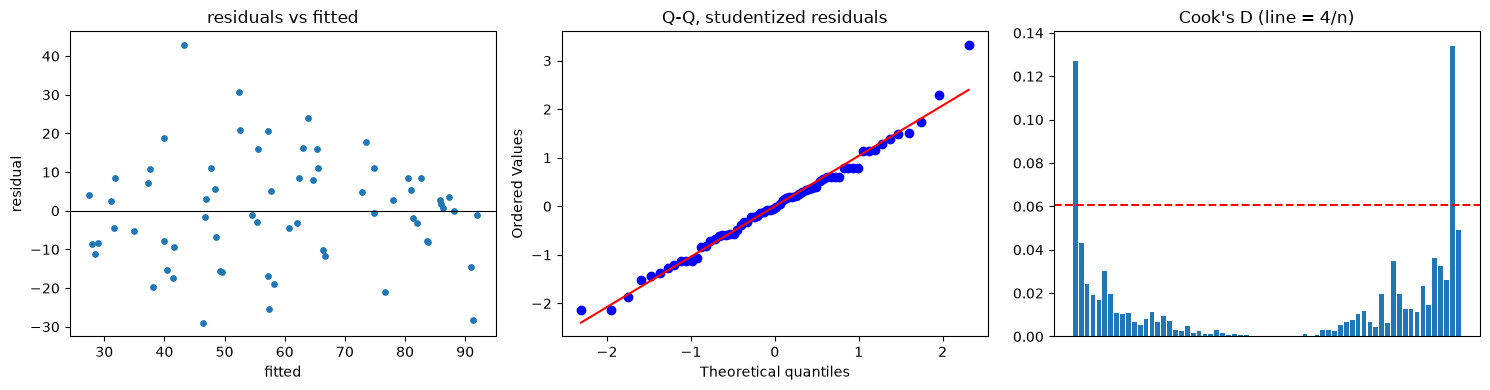

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].scatter(r.fitted, r.resid, s=15); ax[0].axhline(0, c="k", lw=.8); ax[0].set(xlabel="fitted", ylabel="residual", title="residuals vs fitted")
import scipy.stats as st; st.probplot(r.std_resid, plot=ax[1]); ax[1].set_title("Q-Q, studentized residuals")
ax[2].bar(r.country, r.cooks_d); ax[2].axhline(4/len(r), c="r", ls="--"); ax[2].set(title="Cook's D (line = 4/n)"); ax[2].set_xticks([])
plt.tight_layout()

In [4]:
# High-influence points
r[r.cooks_d > 4/len(r)][["country","pua","mddw","resid","std_resid","cooks_d","mddw_source_group"]]

,country,pua,mddw,resid,std_resid,cooks_d,mddw_source_group
0,Indonesia,69.7,86.13,42.807703,3.318622,0.127173,GDQP
64,Malaysia,1.9,62.94,-28.384098,-2.138241,0.134007,GDQP


## The residual list, by quadrant

In [5]:
for q, g in r.groupby("quadrant"):
    print(f"\n== {q} (n={len(g)}) ==")
    print(g.sort_values("resid", ascending=False)[["country","pua","mddw","fitted","resid","std_resid","mddw_source_group","income"]].round(1).to_string(index=False))


== higher unaffordability, higher MDD-W than predicted (n=14) ==
                         country  pua  mddw  fitted  resid  std_resid mddw_source_group              income
                       Indonesia 69.7  86.1    43.3   42.8        3.3              GDQP Upper middle income
                         Armenia 57.0  83.1    52.3   30.8        2.3              GDQP Upper middle income
Lao People's Democratic Republic 56.6  73.4    52.6   20.8        1.5              GDQP Lower middle income
                       Guatemala 50.0  77.8    57.3   20.5        1.5              GDQP Upper middle income
                          Uganda 74.6  58.8    39.9   18.9        1.4              GDQP          Low income
                      Costa Rica 52.5  71.4    55.5   15.9        1.1              GDQP         High income
                            Chad 63.4  58.8    47.8   11.0        0.8              GDQP          Low income
                           Kenya 77.8  48.5    37.6   10.9        0.8 

## Is the residual just survey mode?
DHS-sourced points sit ~13 points below GDQP-sourced points at the same affordability (robustness table). Look at the residual distribution by source and check whether the *named* countries change if we adjust for source.

In [6]:
r.groupby("mddw_source_group").resid.describe().round(1)

,count,mean,std,min,25%,50%,75%,max
mddw_source_group,,,,,,,,
DHS,14.0,-7.3,9.9,-20.9,-15.2,-8.8,1.1,10.9
GDQP,46.0,3.1,14.2,-28.4,-3.2,2.6,10.9,42.8
Other,6.0,-6.4,12.8,-28.9,-8.3,-6.2,0.9,8.4


In [7]:
# Residuals from the source-adjusted model, compared with the headline
adj = smf.ols("mddw ~ pua + C(mddw_source_group, Treatment('GDQP'))", data=r).fit()
r["resid_src_adj"] = adj.resid
cmp = r[["country","mddw_source_group","resid","resid_src_adj"]].copy()
cmp["rank"] = cmp.resid.rank(ascending=False); cmp["rank_adj"] = cmp.resid_src_adj.rank(ascending=False)
cmp.assign(shift=lambda d: d.rank_adj - d["rank"]).sort_values("shift").round(1)

,country,mddw_source_group,resid,resid_src_adj,rank,rank_adj,shift
54,Jordan,DHS,-14.6,-1.4,55.0,37.0,-18.0
41,Lebanon,Other,-4.5,3.0,42.0,25.0,-17.0
28,Mauritius,Other,2.7,12.4,29.0,13.0,-16.0
22,Senegal,DHS,5.1,14.0,23.0,9.0,-14.0
43,Nigeria,DHS,-5.3,0.7,44.0,31.0,-13.0
42,Zambia,DHS,-4.6,1.0,43.0,30.0,-13.0
26,Ghana,DHS,3.0,10.6,27.0,15.0,-12.0
50,Angola,DHS,-9.5,-2.6,51.0,39.0,-12.0
17,Gambia,Other,8.4,16.1,18.0,7.0,-11.0
13,Kenya,DHS,10.9,17.2,14.0,4.0,-10.0


## Residual vs GDP — is the 'non-price constraint' correlated with income?

corr(resid, log gdp) = 0.261


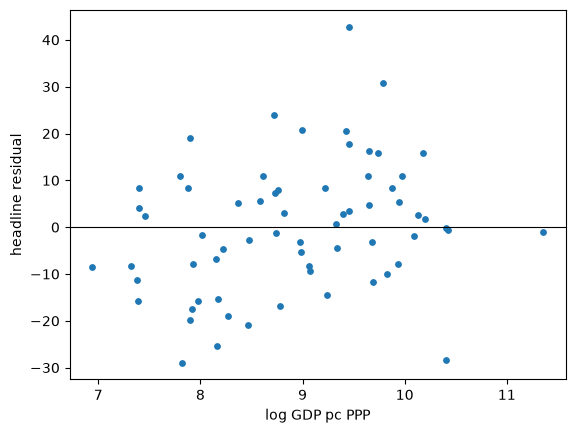

In [8]:
print("corr(resid, log gdp) =", round(np.corrcoef(r.resid, np.log(r.gdp_pcap_ppp))[0,1], 3))
plt.scatter(np.log(r.gdp_pcap_ppp), r.resid, s=15); plt.axhline(0, c="k", lw=.8); plt.xlabel("log GDP pc PPP"); plt.ylabel("headline residual");